# Import libraries

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Import Data

In [2]:
cols = ['Length','Width','Size','Conc','Conc1','Asym','M3Long','M3Trans','Alpha','Dist','Class']
df = pd.read_csv('magic04.csv', names=cols)

In [3]:
profile = ProfileReport(df, title='MAGIC Gamma Telescope EDA Report', explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 66.79it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
df["Class"]=(df["Class"]=="h").astype(int)

X=df.drop("Class",axis=1)
y=df["Class"]

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=44)

# Hyper paramater tuning/Roc curve

In [6]:
models = {
    "SVC": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("SVC", SVC(kernel="linear", class_weight="balanced"))
        ]),
        "params": {
            "SVC__C": [0.01, 0.1, 1, 5]
        }
    },

    "XGBoost": {
        "pipeline": XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=12332 / 6688  # ≈ 1.84
        ),
        "params": {
            "n_estimators": [100, 150, 200],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.05, 0.1, 0.2],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    },

    "LightGBM": {
        "pipeline": LGBMClassifier(
            is_unbalance=True,
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [100, 150, 200],
            "max_depth": [-1, 3, 5],
            "learning_rate": [0.05, 0.1, 0.2],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    },

    "GaussianNB": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("GaussianNB", GaussianNB())
        ]),
        "params": {
            # For GaussianNB, you can tune 'var_smoothing' (numerical stability)
            "GaussianNB__var_smoothing": [1e-9, 1e-8, 1e-7]
        }
    }
}

In [7]:
models_grid = {}

for name, config in models.items():

    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=3,               #  number of random combinations to test
        scoring="roc_auc",
        cv=3,                   # fewer folds for faster run
        n_jobs=-1,              #  parallel execution on all CPU cores
        random_state=42,        #  reproducibility
        verbose=1
    )
    
    search.fit(X, y)
    print(f"Best params for {name}: {search.best_params_}")
    
    models_grid[name] = search


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params for SVC: {'SVC__C': 0.1}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params for XGBoost: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[LightGBM] [Info] Number of positive: 6688, number of negative: 12332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001492 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 19020, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.351630 -> initscore=-0.611883
[LightGBM] [Info] Start training from score -0.611883
Best params for LightGBM: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Fitting 3 folds for each of 3 cand

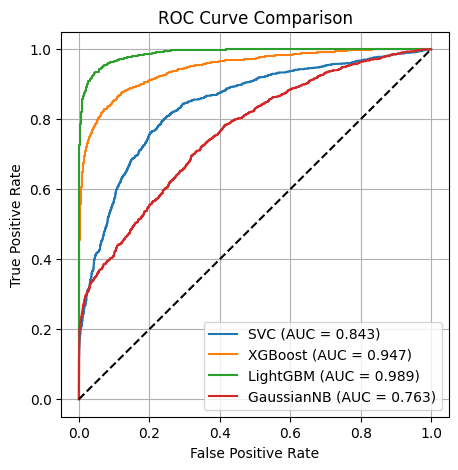

In [8]:
plt.figure(figsize=(5, 5))

for name, grid in models_grid.items():
    # Handle models with/without predict_proba
    if hasattr(grid, "predict_proba"):
        y_scores = grid.predict_proba(X_test)[:, 1]
    else:
        y_scores = grid.decision_function(X_test)

    # Compute ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

# Add reference line
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
chosen_model=models_grid["LightGBM"]
chosen_model.fit(X_train,y_train)
y_pred=chosen_model.predict(X_test)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[LightGBM] [Info] Number of positive: 5303, number of negative: 9913
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 15216, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348515 -> initscore=-0.625574
[LightGBM] [Info] Start training from score -0.625574


In [10]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      2419
           1       0.84      0.83      0.84      1385

    accuracy                           0.88      3804
   macro avg       0.87      0.87      0.87      3804
weighted avg       0.88      0.88      0.88      3804



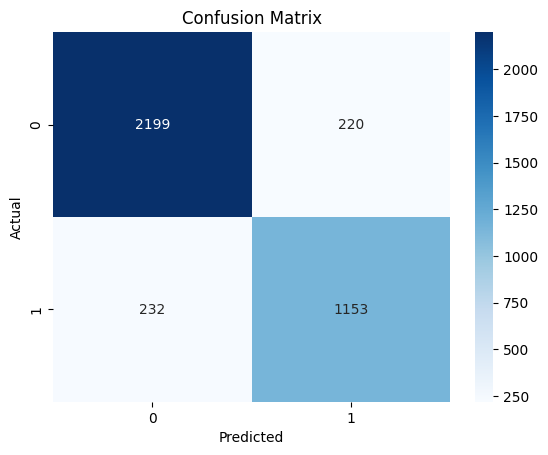

In [11]:
sns.heatmap(confusion_matrix(y_test,y_pred),cmap="Blues",fmt="d",annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()